In [12]:
import sys
import os

# Add parent directory of the notebook to sys.path
sys.path.append(os.path.abspath(".."))

In [13]:
import numpy as np
import pickle as pkl
from plot_params import *
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase



In [15]:


with open('sequential_data.pkl', 'rb') as f:
    k_l, order_k_l, accuracy_k_l, pr_k_l, W_list_l = pkl.load(f)

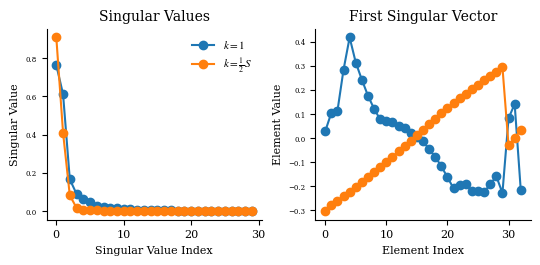

In [21]:

fig, axs = plt.subplots(1, 2, figsize=(FIG_WIDTH, FIG_WIDTH/2))
for i in [0, len(k_l)//2]:
    W_l = W_list_l[i]
    W_eff = W_l[0].T
    for W in W_l[1:]:
        W_eff = W_eff @ W.T
    W_eff /= np.linalg.norm(W_eff)
    U, L, V = np.linalg.svd(W_eff)
    label = r'$k=1$' if i == 0 else r'$k=\frac{1}{2}S$'
    axs[0].plot(L, marker='o', label=label)
    axs[0].set_title('Singular Values')
    axs[1].plot(U[:,0], marker='o')
    axs[1].set_title('First Singular Vector')
axs[0].legend()
plt.tight_layout()
axs[0].set_xlabel('Singular Value Index')
axs[0].set_ylabel('Singular Value')
axs[1].set_xlabel('Element Index')
axs[1].set_ylabel('Element Value')
plt.show()
fig.savefig(r'./final_results/figures/fig_sequential.png', dpi=300, bbox_inches='tight')